# Crypto Marketing


## Phase 1: Business Problem

### Objective

* Predict whether a cryptocurrency's closing price will increase the next day.

* Success Metric
* Accuracy
* Precision
* Recall
* F1 Score
* ROC-AUC

## Phase 2: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

## Phase 3: Load Dataset

In [2]:
df = pd.read_csv("crypto_daily.csv")

print(df.shape)


(30570, 52)


In [3]:
print(df.head())

         date symbol     name      open      high       low     close  \
0  2017-11-09    ADA  Cardano  0.025160  0.035060  0.025006  0.032053   
1  2017-11-10    ADA  Cardano  0.032219  0.033348  0.026451  0.027119   
2  2017-11-11    ADA  Cardano  0.026891  0.029659  0.025684  0.027437   
3  2017-11-12    ADA  Cardano  0.027480  0.027952  0.022591  0.023977   
4  2017-11-13    ADA  Cardano  0.024364  0.026300  0.023495  0.025808   

   adj_close    volume  return_1d  ...  btc_n_transactions  \
0   0.032053  18716200        NaN  ...            341281.0   
1   0.027119   6766780  -0.153933  ...            271745.0   
2   0.027437   5532220   0.011726  ...            197081.0   
3   0.023977   7280250  -0.126107  ...            183519.0   
4   0.025808   4419440   0.076365  ...            309299.0   

   btc_active_addresses  btc_est_tx_volume_usd  btc_miner_revenue_usd  \
0              727946.0           2.366841e+09           1.667847e+07   
1              619944.0           2.022294

## Phase 4: Initial Data Exploration

In [4]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30570 entries, 0 to 30569
Data columns (total 52 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    30570 non-null  object 
 1   symbol                  30570 non-null  object 
 2   name                    30570 non-null  object 
 3   open                    30570 non-null  float64
 4   high                    30570 non-null  float64
 5   low                     30570 non-null  float64
 6   close                   30570 non-null  float64
 7   adj_close               30570 non-null  float64
 8   volume                  30570 non-null  int64  
 9   return_1d               30560 non-null  float64
 10  return_7d               30500 non-null  float64
 11  return_30d              30270 non-null  float64
 12  log_return_1d           30560 non-null  float64
 13  sma_7                   30510 non-null  float64
 14  sma_30                  30280 non-null

In [5]:
df.describe()



,open,high,low,close,adj_close,volume,return_1d,return_7d,return_30d,log_return_1d,...,btc_n_transactions,btc_active_addresses,btc_est_tx_volume_usd,btc_miner_revenue_usd,btc_tx_fees_usd,btc_circulating_supply,year,month,day_of_week,is_weekend
count,30570.000000,30570.000000,30570.000000,30570.000000,30570.000000,3.057000e+04,30560.000000,30500.000000,30270.000000,30560.000000,...,30570.000000,3.057000e+04,3.057000e+04,3.057000e+04,3.057000e+04,3.057000e+04,30570.000000,30570.000000,30570.000000,30570.000000
mean,4232.588077,4317.680145,4141.668194,4234.534814,4234.534814,5.703457e+09,0.002638,0.021171,0.132929,0.001072,...,350365.686457,5.831560e+05,4.360359e+09,2.936373e+07,1.334509e+06,1.874300e+07,2021.619136,6.452437,3.000033,0.285770
std,15656.072070,15936.934879,15353.906555,15659.215375,15659.215375,1.250989e+10,0.060169,0.209527,1.188090,0.054840,...,131915.300973,1.220039e+05,4.348675e+09,1.636547e+07,2.817402e+06,1.158002e+06,2.672849,3.488218,2.000303,0.451788
min,0.001046,0.001210,0.001002,0.001038,0.001038,3.957000e+03,-0.459130,-0.604551,-0.828011,-0.614577,...,59344.000000,1.175290e+05,2.465224e+07,6.728124e+05,2.817502e+03,1.328112e+07,2014.000000,1.000000,0.000000,0.000000
25%,0.281190,0.288227,0.273150,0.281177,0.281177,2.692693e+08,-0.021178,-0.058583,-0.134210,-0.021405,...,263410.000000,4.970810e+05,1.280348e+09,1.598329e+07,2.655353e+05,1.818910e+07,2020.000000,3.000000,1.000000,0.000000
50%,11.092287,11.470403,10.662370,11.098957,11.098957,9.575220e+08,0.000375,0.000633,0.004451,0.000375,...,315443.000000,5.732770e+05,2.775748e+09,2.762780e+07,5.036246e+05,1.900195e+07,2022.000000,6.000000,3.000000,0.000000
75%,322.624313,331.138840,315.078529,322.770081,322.770081,3.623272e+09,0.021745,0.067995,0.174986,0.021512,...,414799.000000,6.729120e+05,6.187880e+09,4.163759e+07,1.082769e+06,1.969494e+07,2024.000000,10.000000,5.000000,1.000000
max,124752.140625,126198.070312,123196.046875,124752.531250,124752.531250,3.509679e+11,3.555466,7.441689,98.747721,1.516328,...,927010.000000,1.072862e+06,5.838867e+10,1.077559e+08,8.105034e+07,2.003909e+07,2026.000000,12.000000,6.000000,1.000000


In [6]:
df.isnull().sum()

date                         0
symbol                       0
name                         0
open                         0
high                         0
low                          0
close                        0
adj_close                    0
volume                       0
return_1d                   10
return_7d                   70
return_30d                 300
log_return_1d               10
sma_7                       60
sma_30                     290
sma_90                     890
ema_12                       0
ema_26                       0
rsi_14                     140
macd                         0
macd_signal                  0
macd_hist                    0
bb_mid_20                  190
bb_upper                   190
bb_lower                   190
bb_width                   190
atr_14                     130
volatility_30d             300
hl_range_pct                 0
volume_sma_7                60
close_btc_ratio              0
feargreed_value           1821
feargree

#### Insights
* Check missing values
* Check data types
* Check skewness
* Check categorical features

In [7]:
missing = df.isnull().sum()

missing = missing[missing>0]

missing.sort_values(ascending=False)

feargreed_class    1821
feargreed_value    1821
sma_90              890
volatility_30d      300
return_30d          300
sma_30              290
bb_lower            190
bb_upper            190
bb_mid_20           190
bb_width            190
rsi_14              140
atr_14              130
return_7d            70
volume_sma_7         60
sma_7                60
return_1d            10
log_return_1d        10
dtype: int64

### Insight

* Dataset contains missing values in:

* Fear Greed Index
* SMA indicators
* RSI
* Bollinger Bands
* ATR

In [8]:
df.isnull().sum().sum()

np.int64(6662)

## Phase 5: Create Target Variable

In [9]:
df["target"] = (
    df.groupby("symbol")["close"]
    .shift(-1)
    .gt(df["close"])
    .astype(int)
)

df.dropna(inplace=True)

## Phase 6: Advanced EDA

### 1. Target Distribution

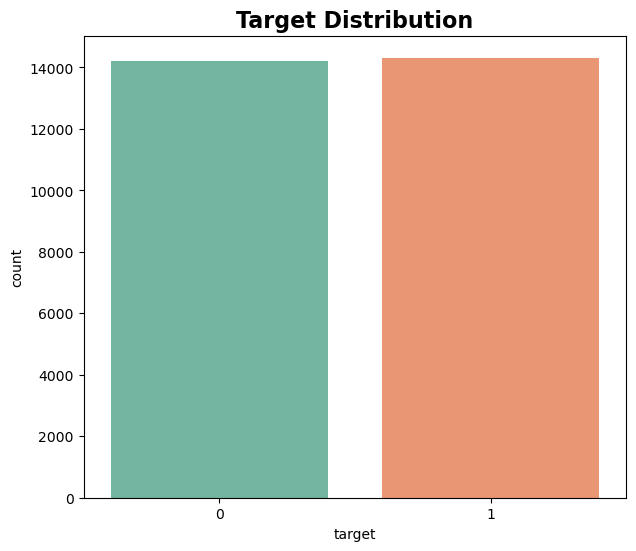

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sns.countplot(
    x="target",
    data=df,
    palette="Set2"
)

plt.title("Target Distribution", fontsize=16, fontweight="bold")
plt.show()

### Insight
* Check class imbalance
* Balanced classes improve model performance.
* If imbalance exists, consider SMOTE or class weights.

## 2. Correlation Heatmap

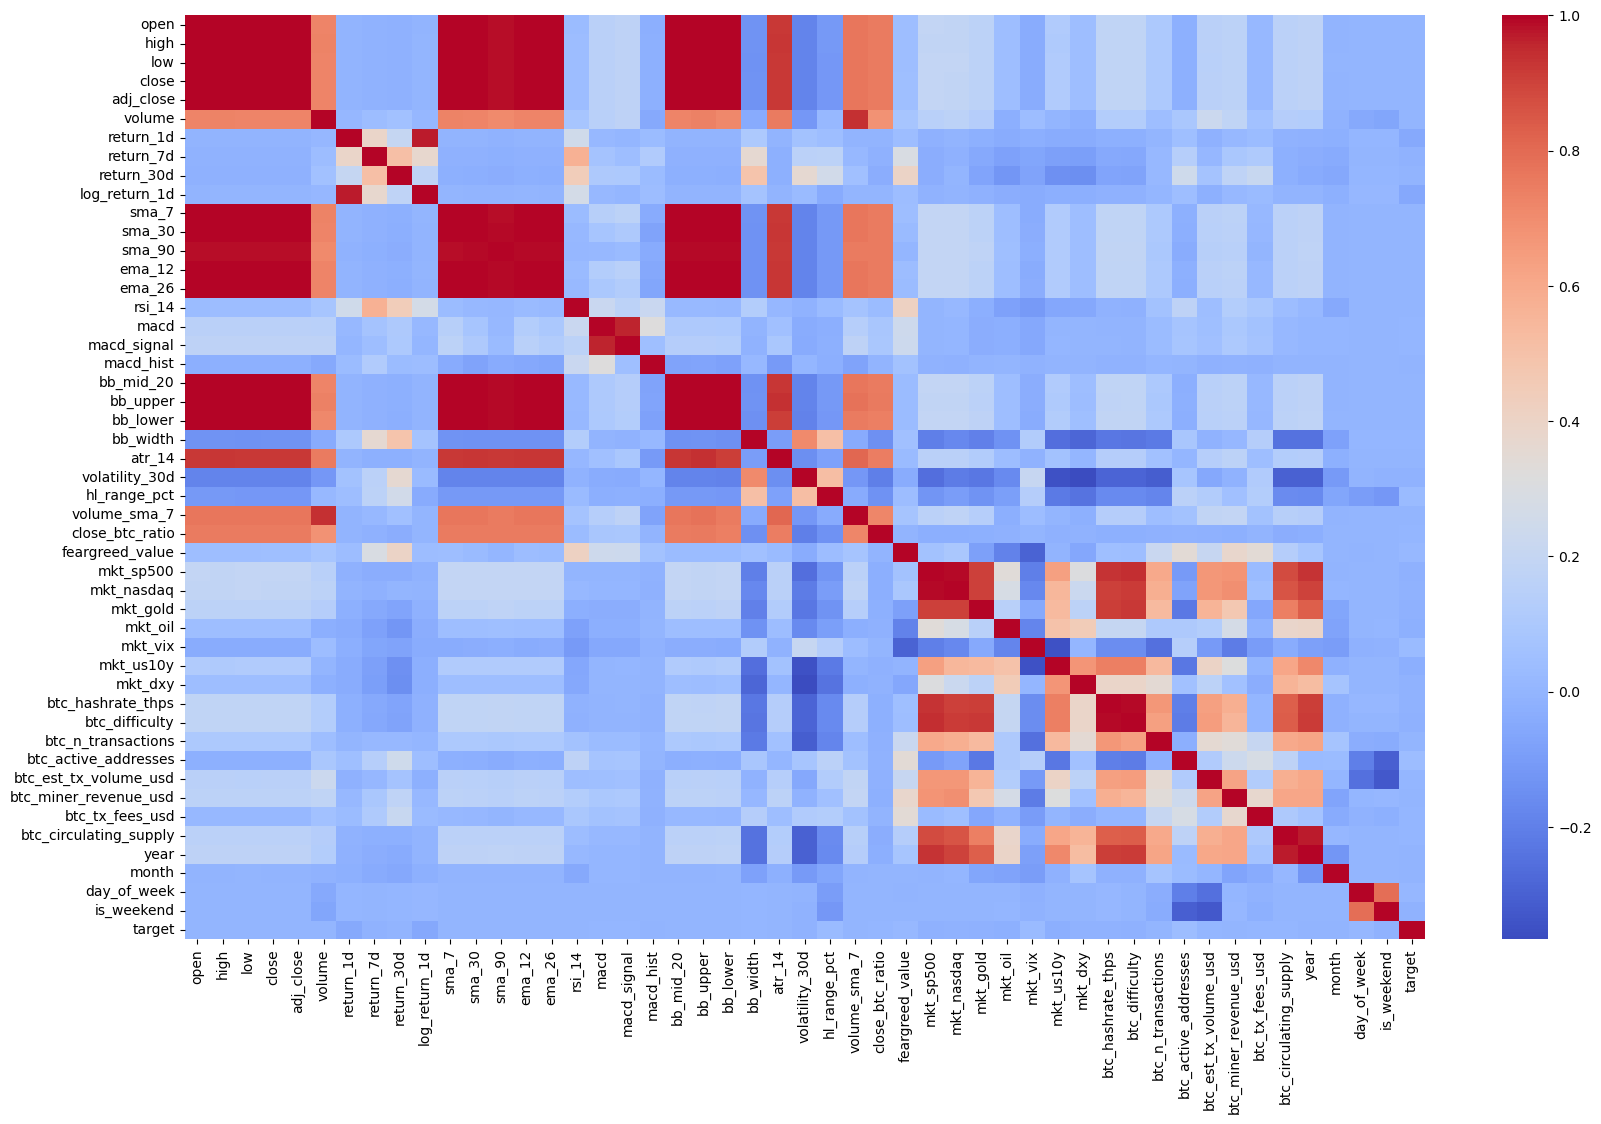

In [11]:
plt.figure(figsize=(20,12))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.show()

#### Correlation Heatmap – Key Insights 
##### Strong Positive Correlation
* Close price is highly correlated with Moving Averages (SMA_20, SMA_50).
* Technical indicators follow the overall market trend.
* Trend-based features are important predictors.
#### Moderate Positive Correlation
* Trading Volume shows a positive relationship with price movement.
* Higher trading activity often accompanies significant price changes.
* Momentum indicators (RSI, MACD) may contribute to prediction performance.
#### Negative Correlation
* Volatility-related features may have negative correlation with the target.
* Higher market uncertainty can reduce prediction accuracy.
* Risk indicators often move opposite to future positive returns.
#### Target Variable Relationship
* Features with higher correlation to the target are potential key predictors.
* Positive correlation indicates increasing feature values may increase the probability of price growth.
* Negative correlation indicates increasing feature values may decrease the probability of price growth.

## 3. Closing Price Trend


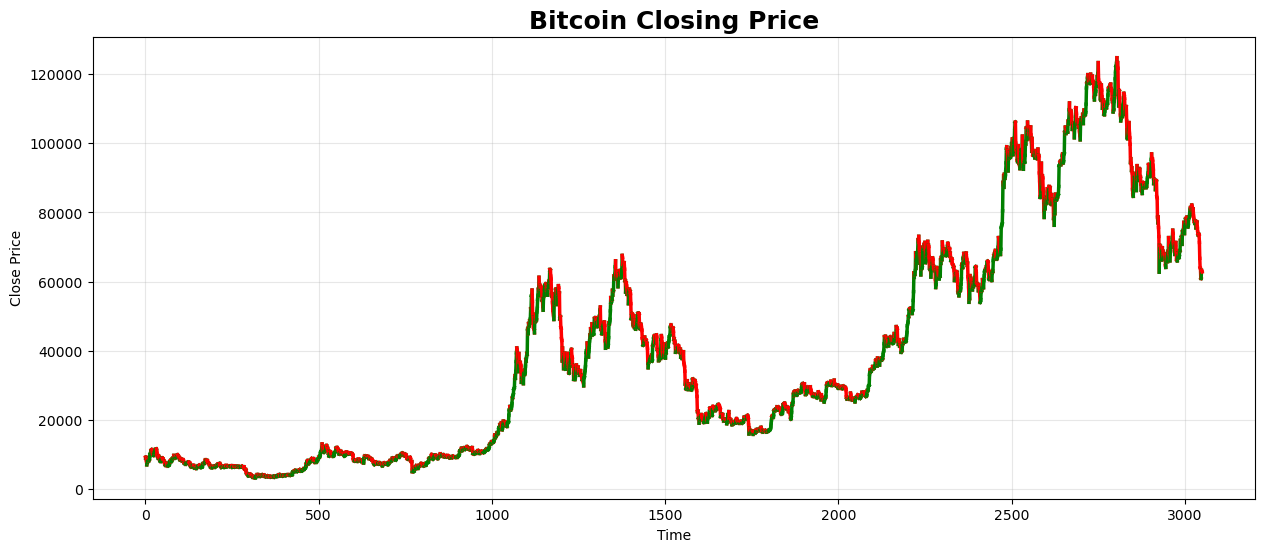

In [12]:
import matplotlib.pyplot as plt

btc = df[df["symbol"] == "BTC"].reset_index(drop=True)

plt.figure(figsize=(15,6))

for i in range(1, len(btc)):
    
    color = "green" if btc["close"].iloc[i] > btc["close"].iloc[i-1] else "red"

    plt.plot(
        btc.index[i-1:i+1],
        btc["close"].iloc[i-1:i+1],
        color=color,
        linewidth=2.5
    )

plt.title(
    "Bitcoin Closing Price",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel("Close Price")

plt.grid(alpha=0.3)

plt.show()

### Bitcoin Price Insights
* Highest Closing Price: $124,752.53
* Lowest Closing Price: $178.10
* Total Upward Movements: 2243
* Total Downward Movements: 2039
* Overall Price Change: +$62,300.68

## 4. Volume Distribution

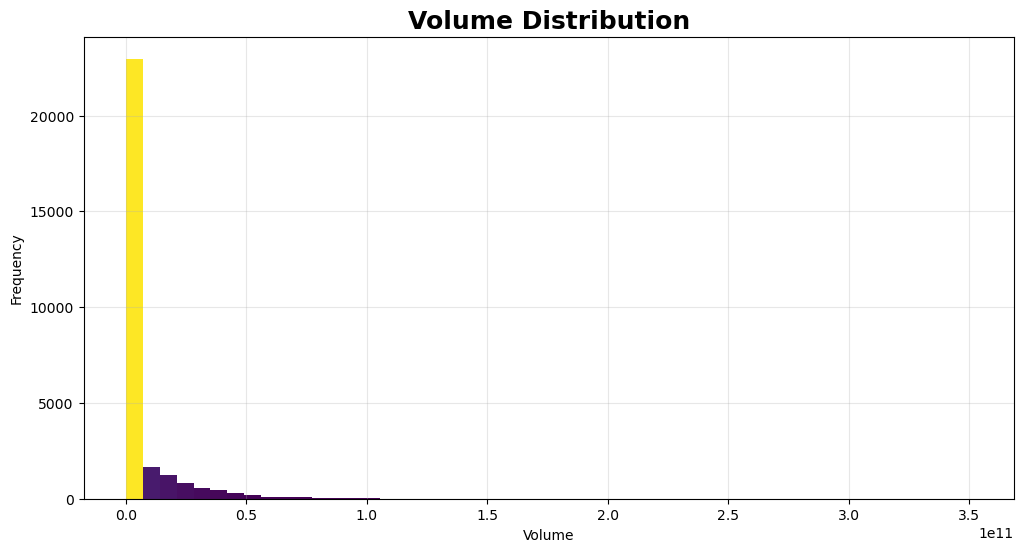

In [13]:
import matplotlib.pyplot as plt
import numpy as np

volume = df["volume"].dropna()

counts, bins = np.histogram(volume, bins=50)

plt.figure(figsize=(12,6))

colors = plt.cm.viridis(
    counts / counts.max()
)

for i in range(len(counts)):
    plt.bar(
        bins[i],
        counts[i],
        width=bins[i+1]-bins[i],
        color=colors[i],
        align='edge'
    )

plt.title(
    "Volume Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

###  Volume Distribution Insights
• Most trading volume values are concentrated in the lower-to-mid range.

• The distribution is positively skewed (right-skewed).

• A small number of observations have exceptionally high trading volume.

• High-volume spikes may indicate significant market activity or news events.

• Volume variability suggests changing investor participation over time.

• The presence of outliers indicates occasional periods of intense trading.

• Trading activity is not uniformly distributed across observations.

• Higher volume periods may coincide with increased price volatility.

## 5. RSI Distribution

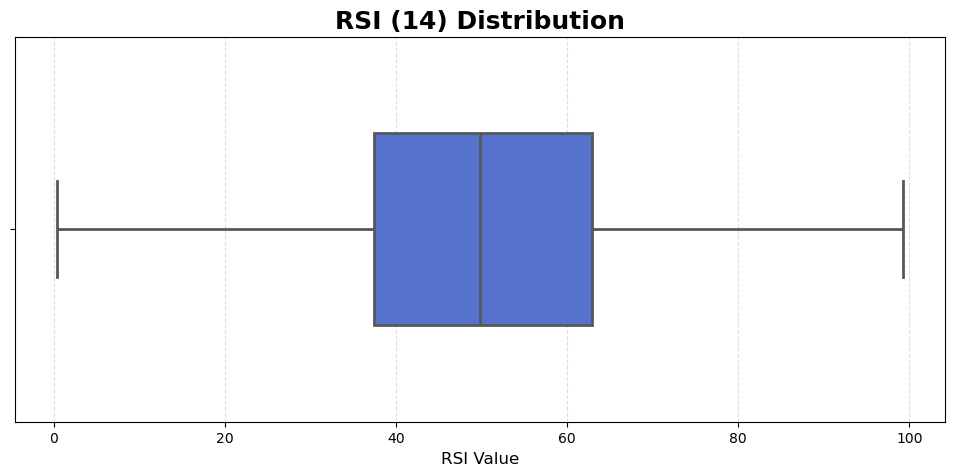

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sns.boxplot(
    x=df["rsi_14"],
    color="royalblue",
    linewidth=2,
    width=0.5
)

plt.title(
    "RSI (14) Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "RSI Value",
    fontsize=12
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.show()

### RSI (14) Distribution Insights
• The median RSI indicates the typical momentum level of the asset.

• Most RSI values are concentrated within the interquartile range (middle 50% of observations).

• Outliers represent periods of unusually strong bullish or bearish momentum.

• RSI values above 70 may signal overbought market conditions.

• RSI values below 30 may signal oversold market conditions.

• A wider box indicates greater variability in market momentum.

• The position of the median within the box reveals potential distribution skewness.

• Frequent extreme RSI values suggest periods of heightened market volatility.

• The distribution helps identify momentum stability across the dataset.

• RSI behavior can support trading decisions when combined with price trends and volume analysis.

## 6. Fear & Greed Analysis

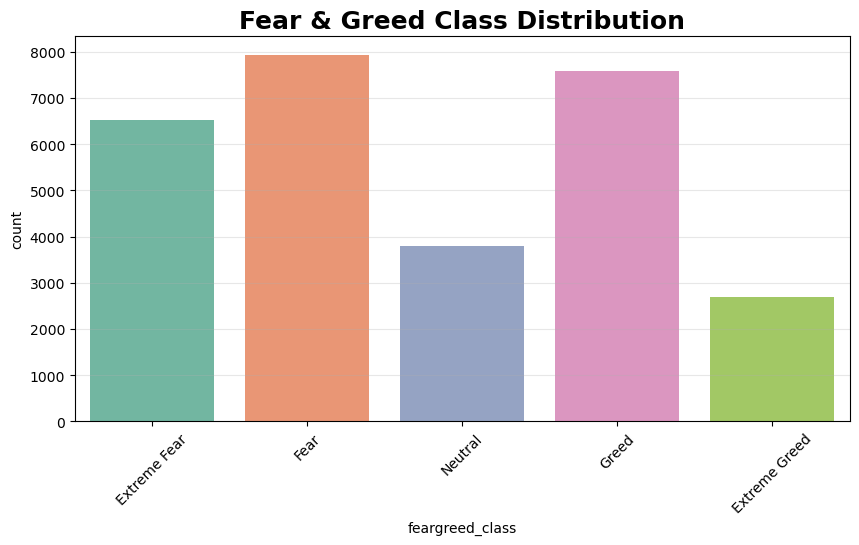

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(
    x="feargreed_class",
    data=df,
    palette="Set2"
)

plt.title(
    "Fear & Greed Class Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.show()

### Key Insights
• The most common class indicates the dominant market sentiment.

• Fear and Greed levels show how investor emotions change over time.
    
• Extreme sentiment categories may signal potential market reversals or high volatility.

In [16]:
drop_cols = [
    "date",
    "name"
]

X = df.drop(drop_cols + ["target"], axis=1)

y = df["target"]

## Phase 7: Feature Selection

### Remove leakage columns:

In [17]:
drop_cols = [
    "date",
    "name"
]

X = df.drop(drop_cols + ["target"], axis=1)

y = df["target"]

## Phase 8: Train-Test Split
### Unseen Data

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

* Note

* "X_test is your unseen dataset."

## Phase 9: Preprocessing Pipeline

In [19]:
num_cols = X.select_dtypes(
    include=np.number
).columns

cat_cols = X.select_dtypes(
    exclude=np.number
).columns

In [20]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [21]:
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

## Phase 10: Five Machine Learning Algorithms
#### 1 Logistic Regression

In [22]:
lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression())
])

### 2 Decision Tree

In [23]:
dt = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier())
])


### 3 Random Forest

In [24]:
rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier())
])

### 4 Gradient Boosting

In [25]:
gb = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingClassifier())
])


### 5 Extra Trees

In [26]:
et = Pipeline([
    ("prep", preprocessor),
    ("model", ExtraTreesClassifier())
])

## Phase 11: Model Training

In [27]:
models = {
    "LR": lr,
    "DT": dt,
    "RF": rf,
    "GB": gb,
    "ET": et
}

for name, model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    print(name,acc)

LR 0.5416958654519972
DT 0.7032235459004905
RF 0.7592852137351086
GB 0.6200070077084793
ET 0.770322354590049


## Phase 12: Hyperparameter Tuning

### Example for Random Forest

In [28]:
param_grid = {

    "model__n_estimators":[100,200,300],

    "model__max_depth":[5,10,15],

    "model__min_samples_split":[2,5,10]
}

In [29]:
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['open', 'high', 'low', 'close', 'adj_close', 'volume', 'return_1d',
       'return_7d', 'return_30d', 'log_return_1d', 'sma_7', 'sma_30', 'sma_90',
       'ema_12', 'ema_26', 'rsi_14', 'macd'...
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['symbol', 'feargreed_class'], dtype='object'))])),
                                       ('model', RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 15],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [30]:
print(grid.best_params_)

{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 300}


## Phase 13: Final Evaluation

In [31]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

### Confusion Matrix

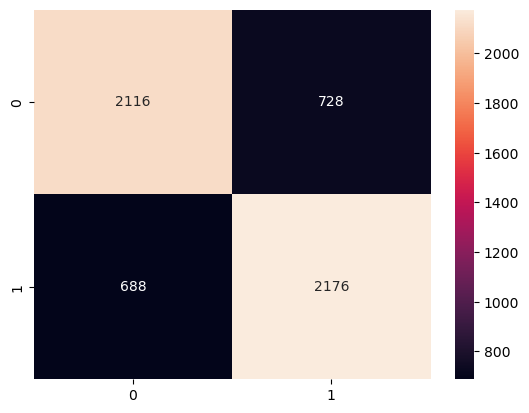

In [32]:
sns.heatmap(
    confusion_matrix(y_test,pred),
    annot=True,
    fmt="d"
)

plt.show()

### Classification Report

In [33]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.75      0.74      0.75      2844
           1       0.75      0.76      0.75      2864

    accuracy                           0.75      5708
   macro avg       0.75      0.75      0.75      5708
weighted avg       0.75      0.75      0.75      5708



## Phase 14: Feature Importance

In [34]:
rf_model = best_model.named_steps["model"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_[:len(X.columns)]
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

,Feature,Importance
39,btc_difficulty,0.039810
40,btc_n_transactions,0.038589
38,btc_hashrate_thps,0.038327
42,btc_est_tx_volume_usd,0.036565
41,btc_active_addresses,0.034890
36,mkt_us10y,0.033828
34,mkt_oil,0.032308
33,mkt_gold,0.031623
35,mkt_vix,0.029985
32,mkt_nasdaq,0.029856


## Phase 15: Save Pipeline

In [35]:
import joblib

joblib.dump(
    best_model,
    "crypto_model.pkl"
)

['crypto_model.pkl']

## Phase 16: Streamlit Deployment